# Week 06 — EDA Precision Lab

## Part A — Dataset Generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (50 + 2.6*study_hours + 0.15*attendance_pct + section_bonus + noise).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})


## Dataset Shape

Check the number of rows and columns in the dataset.

In [2]:
students.shape

(600, 6)

## Dataset Information

Check the column names, data types, and non-null values.

In [3]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             600 non-null    int64  
 1   class_section          600 non-null    object 
 2   study_hours_per_week   600 non-null    float64
 3   sleep_hours_per_night  600 non-null    float64
 4   attendance_pct         600 non-null    float64
 5   exam_score             600 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 28.2+ KB


## Missing Values

Check whether the dataset contains any missing values.

In [4]:
students.isnull().sum()

student_id               0
class_section            0
study_hours_per_week     0
sleep_hours_per_night    0
attendance_pct           0
exam_score               0
dtype: int64

## Duplicate Rows

Check whether the dataset contains any duplicate rows.

In [5]:
students.duplicated().sum()

np.int64(0)

## Descriptive Statistics

Review the basic statistical summary of the numerical variables.

In [6]:
students.describe()

,student_id,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,10.089333,7.046000,85.583000,88.605000
std,173.349358,3.407213,1.122787,9.137597,10.205279
min,1.000000,0.400000,3.400000,62.000000,58.900000
25%,150.750000,7.700000,6.275000,78.900000,81.750000
50%,300.500000,10.000000,7.100000,85.700000,90.200000
75%,450.250000,12.500000,7.800000,92.325000,98.700000
max,600.000000,21.900000,10.000000,100.000000,100.000000


## 2. Genuine Relationship — Study Hours vs Exam Score

Does study time have a relationship with exam score?
A scatter plot is appropriate because both study hours and exam score are continuous numerical variables. Pearson correlation will be used to measure the strength and direction of their linear relationship.

In [7]:
r_study = students["study_hours_per_week"].corr(students["exam_score"])

print(f"Pearson correlation (r): {r_study:.4f}")

Pearson correlation (r): 0.6895


### Pearson Correlation

The Pearson correlation between study hours per week and exam score is **r = 0.6895**, indicating a moderate positive linear relationship between the two variables.

### Study Hours vs Exam Score — Scatter Plot

A scatter plot is used to visualize the relationship between study hours per week and exam score. A fitted trend line is added to show the overall direction of the relationship.

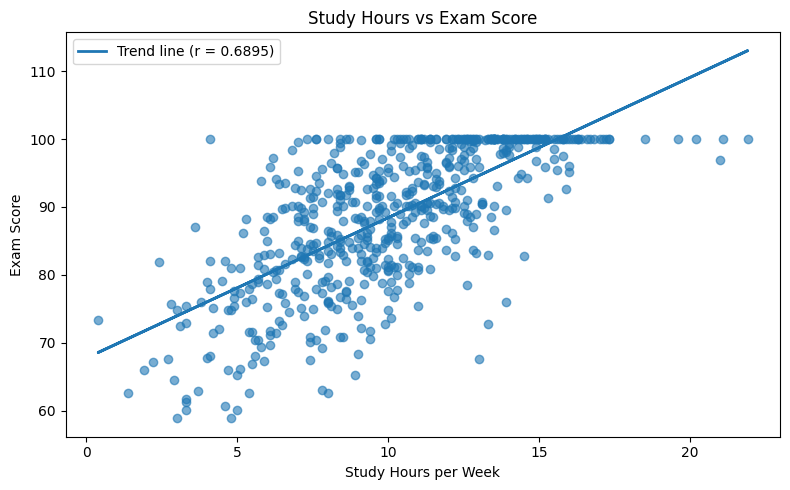

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    students["study_hours_per_week"],
    students["exam_score"],
    alpha=0.6
)

x = students["study_hours_per_week"]
y = students["exam_score"]

slope, intercept = np.polyfit(x, y, 1)

ax.plot(
    x,
    slope * x + intercept,
    linewidth=2,
    label=f"Trend line (r = {r_study:.4f})"
)

ax.set_title("Study Hours vs Exam Score")
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")
ax.legend()

fig.tight_layout()

fig.savefig("Figures/study_hours_vs_exam_score.png", dpi=300, bbox_inches="tight")

plt.show()

In [9]:
study_finding = (
    f"Study hours per week and exam score show a moderate positive linear "
    f"relationship, with a Pearson correlation of r = {r_study:.4f}. "
    f"This indicates that students who study more hours per week tend to "
    f"have higher exam scores in this dataset."
)

print(study_finding)

Study hours per week and exam score show a moderate positive linear relationship, with a Pearson correlation of r = 0.6895. This indicates that students who study more hours per week tend to have higher exam scores in this dataset.


## Finding

Study hours per week and exam score show a moderate positive linear relationship, with a Pearson correlation of r = 0.6895. This indicates that students who study more hours per week tend to have higher exam scores in this dataset.

## Finding

Study hours per week and exam score show a moderate positive linear relationship, with a Pearson correlation of r = 0.6895. This indicates that students who study more hours per week tend to have higher exam scores in this dataset.

## 3. Null Relationship — Sleep Hours vs Exam Score

Does sleep time have a meaningful relationship with exam score?

A scatter plot is appropriate because both sleep hours and exam score are continuous numerical variables. Pearson correlation will be used to determine the strength and direction of their linear relationship.

In [10]:
r_sleep = students["sleep_hours_per_night"].corr(students["exam_score"])

print(f"Pearson correlation (r): {r_sleep:.4f}")

Pearson correlation (r): -0.0217


### Pearson Correlation

The Pearson correlation between sleep hours per night and exam score is **r = -0.0217**, indicating a negligible linear relationship between the two variables.

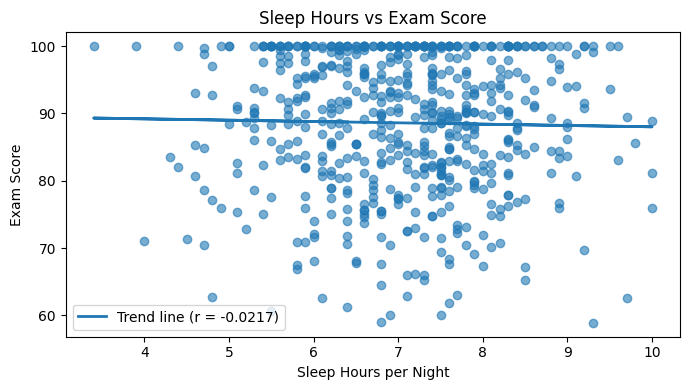

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(
    students["sleep_hours_per_night"],
    students["exam_score"],
    alpha=0.6
)

x = students["sleep_hours_per_night"]
y = students["exam_score"]

slope, intercept = np.polyfit(x, y, 1)

ax.plot(
    x,
    slope * x + intercept,
    linewidth=2,
    label=f"Trend line (r = {r_sleep:.4f})"
)

ax.set_title("Sleep Hours vs Exam Score")
ax.set_xlabel("Sleep Hours per Night")
ax.set_ylabel("Exam Score")
ax.legend()

fig.tight_layout()

fig.savefig(
    "Figures/sleep_hours_vs_exam_score.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [21]:
sleep_finding = (
    f"Sleep hours per night show no meaningful linear relationship with exam score "
    f"in this dataset, with a Pearson correlation of r = {r_sleep:.4f}. "
    f"The near-zero correlation indicates that variation in sleep hours is not "
    f"linearly associated with variation in exam scores in this dataset."
)

print(sleep_finding)

Sleep hours per night show no meaningful linear relationship with exam score in this dataset, with a Pearson correlation of r = -0.0217. The near-zero correlation indicates that variation in sleep hours is not linearly associated with variation in exam scores in this dataset.


## Finding

Sleep hours per night show no meaningful linear relationship with exam score in this dataset, with a Pearson correlation of r = -0.0217. The near-zero correlation indicates that variation in sleep hours is not linearly associated with variation in exam scores in this dataset.

## 4. Genuine Comparison — Exam Score by Class Section

How do exam scores compare across class sections?

A bar chart is appropriate because class section is a categorical variable and exam score is a continuous numerical variable. The sections can be compared regardless of their order, so this is a categorical comparison rather than a relationship.

In [22]:
section_means = students.groupby("class_section")["exam_score"].mean()

print(section_means)

class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64


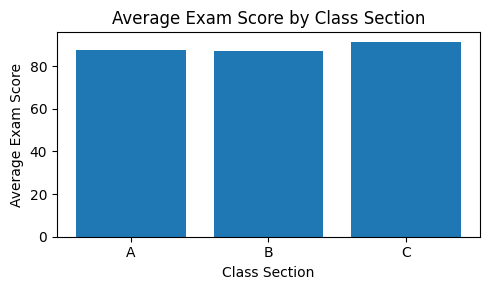

In [23]:
section_means = section_means.reindex(["A", "B", "C"])

fig, ax = plt.subplots(figsize=(5, 3))

ax.bar(
    section_means.index,
    section_means.values
)

ax.set_title("Average Exam Score by Class Section")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()

fig.savefig(
    "Figures/exam_score_by_class_section.png",
    dpi=100
)

plt.show()
plt.close(fig)

In [24]:
section_means = students.groupby("class_section")["exam_score"].mean()

print(section_means)

class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64


In [25]:
shuffled_means = section_means.reindex(["C", "A", "B"])

print(shuffled_means)

class_section
C    91.362632
A    87.608491
B    87.025758
Name: exam_score, dtype: float64


In [26]:
section_means = students.groupby("class_section")["exam_score"].mean()

mean_a = section_means.loc["A"]
mean_b = section_means.loc["B"]
mean_c = section_means.loc["C"]

ab_difference = abs(mean_a - mean_b)
c_vs_a = mean_c - mean_a
c_vs_b = mean_c - mean_b

print("### Findings")
print(
    f"- Section C has the highest average exam score ({mean_c:.2f}), "
    f"followed by Section A ({mean_a:.2f}) and Section B ({mean_b:.2f})."
)
print(
    f"- Sections A and B have very similar average scores, "
    f"with a difference of only {ab_difference:.2f} points."
)
print(
    f"- Section C's average is {c_vs_a:.2f} points higher than A "
    f"and {c_vs_b:.2f} points higher than B."
)

### Findings
- Section C has the highest average exam score (91.36), followed by Section A (87.61) and Section B (87.03).
- Sections A and B have very similar average scores, with a difference of only 0.58 points.
- Section C's average is 3.75 points higher than A and 4.34 points higher than B.


## Findings

- Section C has the highest average exam score (91.36), followed by Section A (87.61) and Section B (87.03).

- Sections A and B have very similar average scores, with a difference of only 0.58 points.

- Section C's average is 3.75 points higher than A and 4.34 points higher than B.

## 5. The Line-Chart Trap
What false impression is created when category averages are connected with a line?

A line chart will be intentionally used on the class-section averages to demonstrate why connecting unordered categories can be misleading.

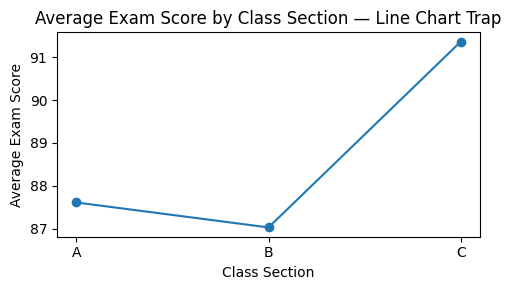

In [28]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(
    section_means.index,
    section_means.values,
    marker="o"
)

ax.set_title("Average Exam Score by Class Section — Line Chart Trap")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()

fig.savefig(
    "Figures/class_section_line_chart_trap.png",
    dpi=100
)

plt.show()
plt.close(fig)

### Finding

The line chart creates a false impression of a continuous trend between Sections A, B, and C. The upward or downward movement of the line suggests that exam scores change progressively from one section to the next, even though class sections are unordered categories. The bar chart is more appropriate because it compares the average exam scores of separate groups without implying movement or continuity between them.

### Shuffle Test

The category order is changed from A → B → C to C → A → B to verify whether changing the order changes the visual pattern of the line chart.

In [29]:
shuffled_means = section_means.reindex(["C", "A", "B"])

print("Original order:")
print(section_means)

print("\nShuffled order:")
print(shuffled_means)

Original order:
class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64

Shuffled order:
class_section
C    91.362632
A    87.608491
B    87.025758
Name: exam_score, dtype: float64


## 5. The Line-Chart Trap — Original vs Shuffled Order

A line chart is intentionally used to connect the mean exam scores of the categorical variable `class_section`. The category order is then changed from A → B → C to C → A → B. This demonstrates how changing the order of unordered categories changes the visual pattern of the line, even though the underlying values remain unchanged.

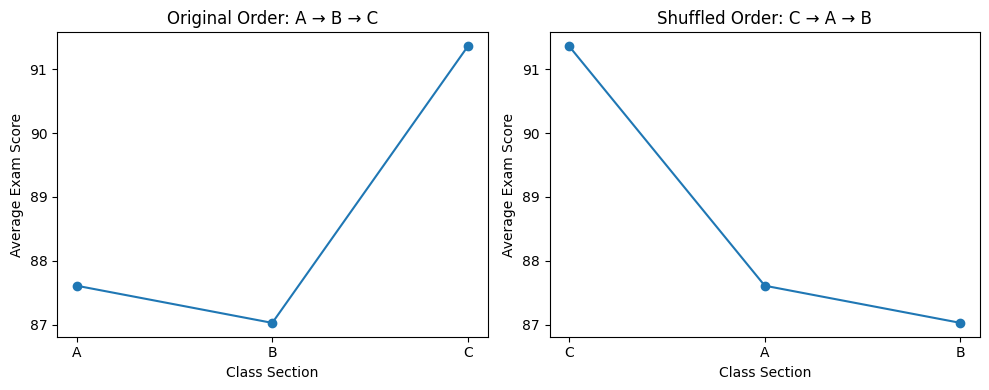

In [30]:
shuffled_means = section_means.reindex(["C", "A", "B"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Original order
axes[0].plot(
    section_means.index,
    section_means.values,
    marker="o"
)

axes[0].set_title("Original Order: A → B → C")
axes[0].set_xlabel("Class Section")
axes[0].set_ylabel("Average Exam Score")

# Shuffled order
axes[1].plot(
    shuffled_means.index,
    shuffled_means.values,
    marker="o"
)

axes[1].set_title("Shuffled Order: C → A → B")
axes[1].set_xlabel("Class Section")
axes[1].set_ylabel("Average Exam Score")

fig.tight_layout()

fig.savefig(
    "Figures/class_section_line_chart_trap_comparison.png",
    dpi=100
)

plt.show()
plt.close(fig)

### Finding

The two line charts contain the same average exam scores, but changing the category order changes the visual pattern of the line. In the original A → B → C order, the chart appears to show a dip from A to B followed by an increase to C. After changing the order to C → A → B, a different pattern appears even though none of the underlying values changed. This demonstrates the false impression created by connecting unordered categories with a line. A bar chart is therefore more appropriate for comparing average exam scores across class sections.

## 6. Visual QA — Deliberate Layout Collision

A chart is not complete when it only looks correct inside the notebook. The saved PNG must also be checked at its actual size. In this step, an annotation will intentionally be placed where it overlaps another chart element, and the layout will then be fixed.

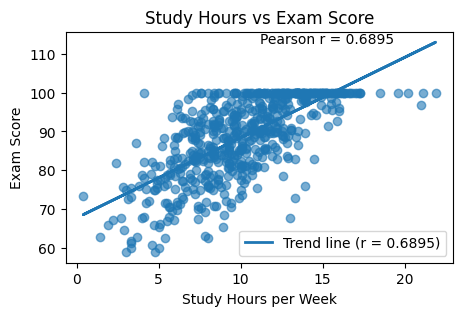

In [31]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(
    students["study_hours_per_week"],
    students["exam_score"],
    alpha=0.6
)

x = students["study_hours_per_week"]
y = students["exam_score"]

slope, intercept = np.polyfit(x, y, 1)

ax.plot(
    x,
    slope * x + intercept,
    linewidth=2,
    label=f"Trend line (r = {r_study:.4f})"
)

ax.set_title("Study Hours vs Exam Score")
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")

ax.legend()

# Deliberately place annotation where it may overlap
ax.text(
    0.5,
    0.95,
    f"Pearson r = {r_study:.4f}",
    transform=ax.transAxes,
    fontsize=10
)

fig.savefig(
    "Figures/study_hours_layout_broken.png",
    dpi=100
)

plt.show()
plt.close(fig)

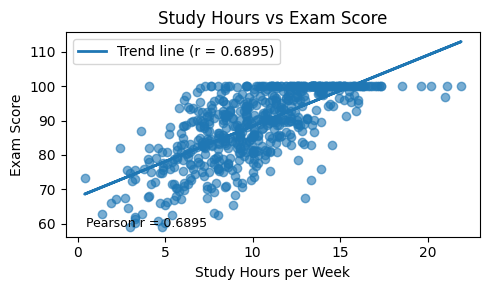

In [32]:
## FIX THe above issue
fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(
    students["study_hours_per_week"],
    students["exam_score"],
    alpha=0.6
)

x = students["study_hours_per_week"]
y = students["exam_score"]

slope, intercept = np.polyfit(x, y, 1)

ax.plot(
    x,
    slope * x + intercept,
    linewidth=2,
    label=f"Trend line (r = {r_study:.4f})"
)

ax.set_title("Study Hours vs Exam Score")
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")

ax.legend()

# Repositioned annotation
ax.text(
    0.05,
    0.05,
    f"Pearson r = {r_study:.4f}",
    transform=ax.transAxes,
    fontsize=9
)

fig.tight_layout()

fig.savefig(
    "Figures/study_hours_layout_fixed.png",
    dpi=100
)

plt.show()
plt.close(fig)

## 7. Color and Category Order

Color and category order can affect how a comparison chart is interpreted. In this step, the same comparison will be shown with arbitrary colors and then with a consistent color choice. The class sections will remain in their natural order: A, B, C, rather than being sorted by their mean scores.

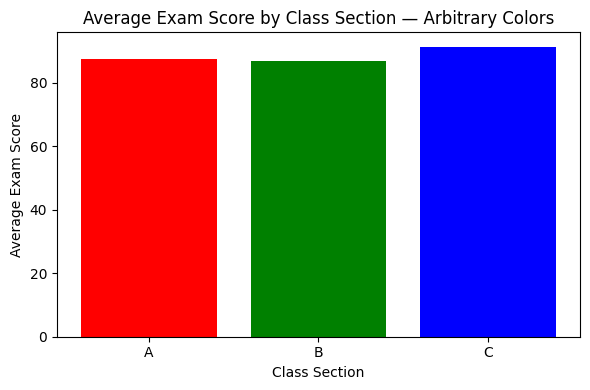

In [33]:
## ARbitrary color chart
section_means = students.groupby("class_section")["exam_score"].mean()

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["A", "B", "C"],
    section_means.loc[["A", "B", "C"]],
    color=["red", "green", "blue"]
)

ax.set_title("Average Exam Score by Class Section — Arbitrary Colors")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()

fig.savefig(
    "Figures/section_comparison_arbitrary_colors.png",
    dpi=100
)

plt.show()
plt.close(fig)

### Arbitrary Colors

This version deliberately uses different arbitrary colors for each class section. The colors do not represent any meaningful property of the data, such as score level, priority, or category type. This is included to demonstrate why arbitrary colors should generally be avoided in a categorical comparison chart when color is not encoding additional information.

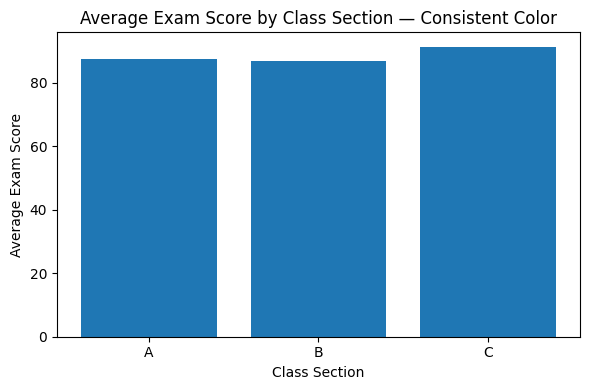

In [34]:

## Correct Color usage
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["A", "B", "C"],
    section_means.loc[["A", "B", "C"]]
)

ax.set_title("Average Exam Score by Class Section — Consistent Color")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()

fig.savefig(
    "Figures/section_comparison_consistent_color.png",
    dpi=100
)

plt.show()
plt.close(fig)

## Step 7 Findings — Color and Category Order

The arbitrary-color chart uses different colors for each class section, but the colors do not provide any additional information. This can make the chart visually distracting and may imply differences that are not actually meaningful.

The consistent-color chart is clearer because the same visual treatment is used for all sections. Since color is not representing another variable, using one consistent color avoids unnecessary visual emphasis.

The category order remains A → B → C in both charts. This preserves the natural order of the class sections instead of sorting them by their average exam scores.

## 8. Labels and Readability

Clear labels are important because they help the reader understand what each axis and category represents. A chart should not require the reader to guess the meaning of its values or labels.

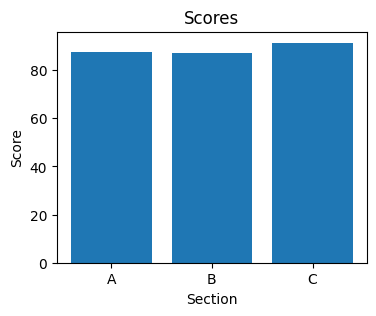

In [35]:
## Poor labeling
fig, ax = plt.subplots(figsize=(4, 3))

ax.bar(
    ["A", "B", "C"],
    section_means.loc[["A", "B", "C"]]
)

ax.set_title("Scores")
ax.set_xlabel("Section")
ax.set_ylabel("Score")

fig.savefig(
    "Figures/section_comparison_poor_readability.png",
    dpi=100
)

plt.show()
plt.close(fig)

### 8.1 Comparison Chart — Poor Readability

This version intentionally uses a small figure size and generic labels to demonstrate a readability problem. The title and axis labels do not clearly describe the information being presented, so the reader has to infer what the scores represent.

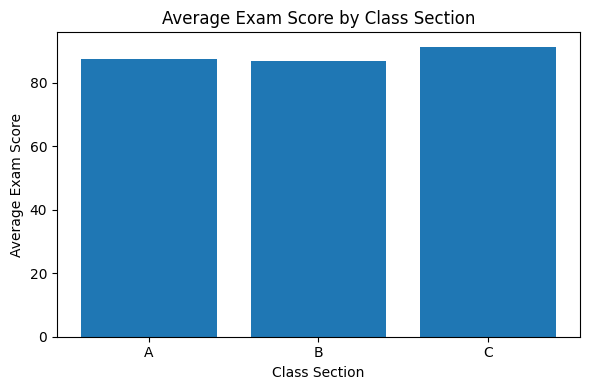

In [36]:
## Improved label and readability
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["A", "B", "C"],
    section_means.loc[["A", "B", "C"]]
)

ax.set_title("Average Exam Score by Class Section")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()

fig.savefig(
    "Figures/section_comparison_improved_readability.png",
    dpi=100
)

plt.show()
plt.close(fig)

## Step 8 Findings — Labels and Readability

The poor-readability version uses a small figure and generic labels such as "Scores" and "Section". Although the chart is still understandable, the labels do not provide enough context and the layout is less comfortable to read.

The improved version uses a larger figure and descriptive labels. The title clearly identifies the comparison, while the x-axis and y-axis labels explain the class sections and average exam scores.

This shows that clear labels, appropriate figure size, and proper layout are important for making charts easy to understand without requiring additional explanation.

## Final Visual QA Findings

The visualizations were reviewed using the saved PNG files rather than relying only on the notebook display.

The comparison charts maintain the natural category order A → B → C. The color comparison showed that arbitrary colors can add unnecessary visual emphasis, while a consistent color provides a cleaner presentation.

The readability comparison showed that descriptive titles, meaningful axis labels, appropriate figure size, and proper layout make the chart easier to understand.

The final visual QA also confirmed that the saved figures should be checked for clipping, overlapping elements, and other layout issues before they are considered complete.

Overall, the visualization process demonstrates that creating a chart is not enough; the final output should also be visually inspected and validated.

## Step 8 — Self-Audit

The reported findings are verified by independently recomputing the two Pearson correlations and one section mean. The claimed values are compared with freshly recomputed values to ensure that every number reported in the findings matches the data.

In [37]:
# Fresh independent recomputation

audit_study_r = students["study_hours_per_week"].corr(
    students["exam_score"]
)

audit_sleep_r = students["sleep_hours_per_night"].corr(
    students["exam_score"]
)

audit_section_a_mean = students.loc[
    students["class_section"] == "A",
    "exam_score"
].mean()

self_audit = pd.DataFrame({
    "Metric": [
        "Study Hours vs Exam Score Correlation",
        "Sleep Hours vs Exam Score Correlation",
        "Section A Mean Exam Score"
    ],
    "Claimed Value": [
        r_study,
        r_sleep,
        mean_a
    ],
    "Freshly Recomputed Value": [
        audit_study_r,
        audit_sleep_r,
        audit_section_a_mean
    ]
})

self_audit["Match"] = (
    self_audit["Claimed Value"] == self_audit["Freshly Recomputed Value"]
)

self_audit

,Metric,Claimed Value,Freshly Recomputed Value,Match
0,Study Hours vs Exam Score Correlation,0.689476,0.689476,True
1,Sleep Hours vs Exam Score Correlation,-0.021658,-0.021658,True
2,Section A Mean Exam Score,87.608491,87.608491,True
